In [1]:
from src import clustering, graph_utils, plotting
import squidpy as sq
import scanpy as sc
import warnings
warnings.filterwarnings("ignore")

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad("C://Users//laure//Desktop//github//adaptive_niche_data//cosmx.h5ad")
adata = adata[adata.obs["section"] == "section_4", :].copy()

In [3]:
clustering.fit_gmm(adata, nn_distance=1, k_range=range(1,10)) #calculates distance to 1st nearest neighbor, then fits GMMs and chooses best one based on ICL
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=20) #no reason to wrap this in another function
graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")
clustering.watershed(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities", niche_key="watershed")

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
assigning colors...


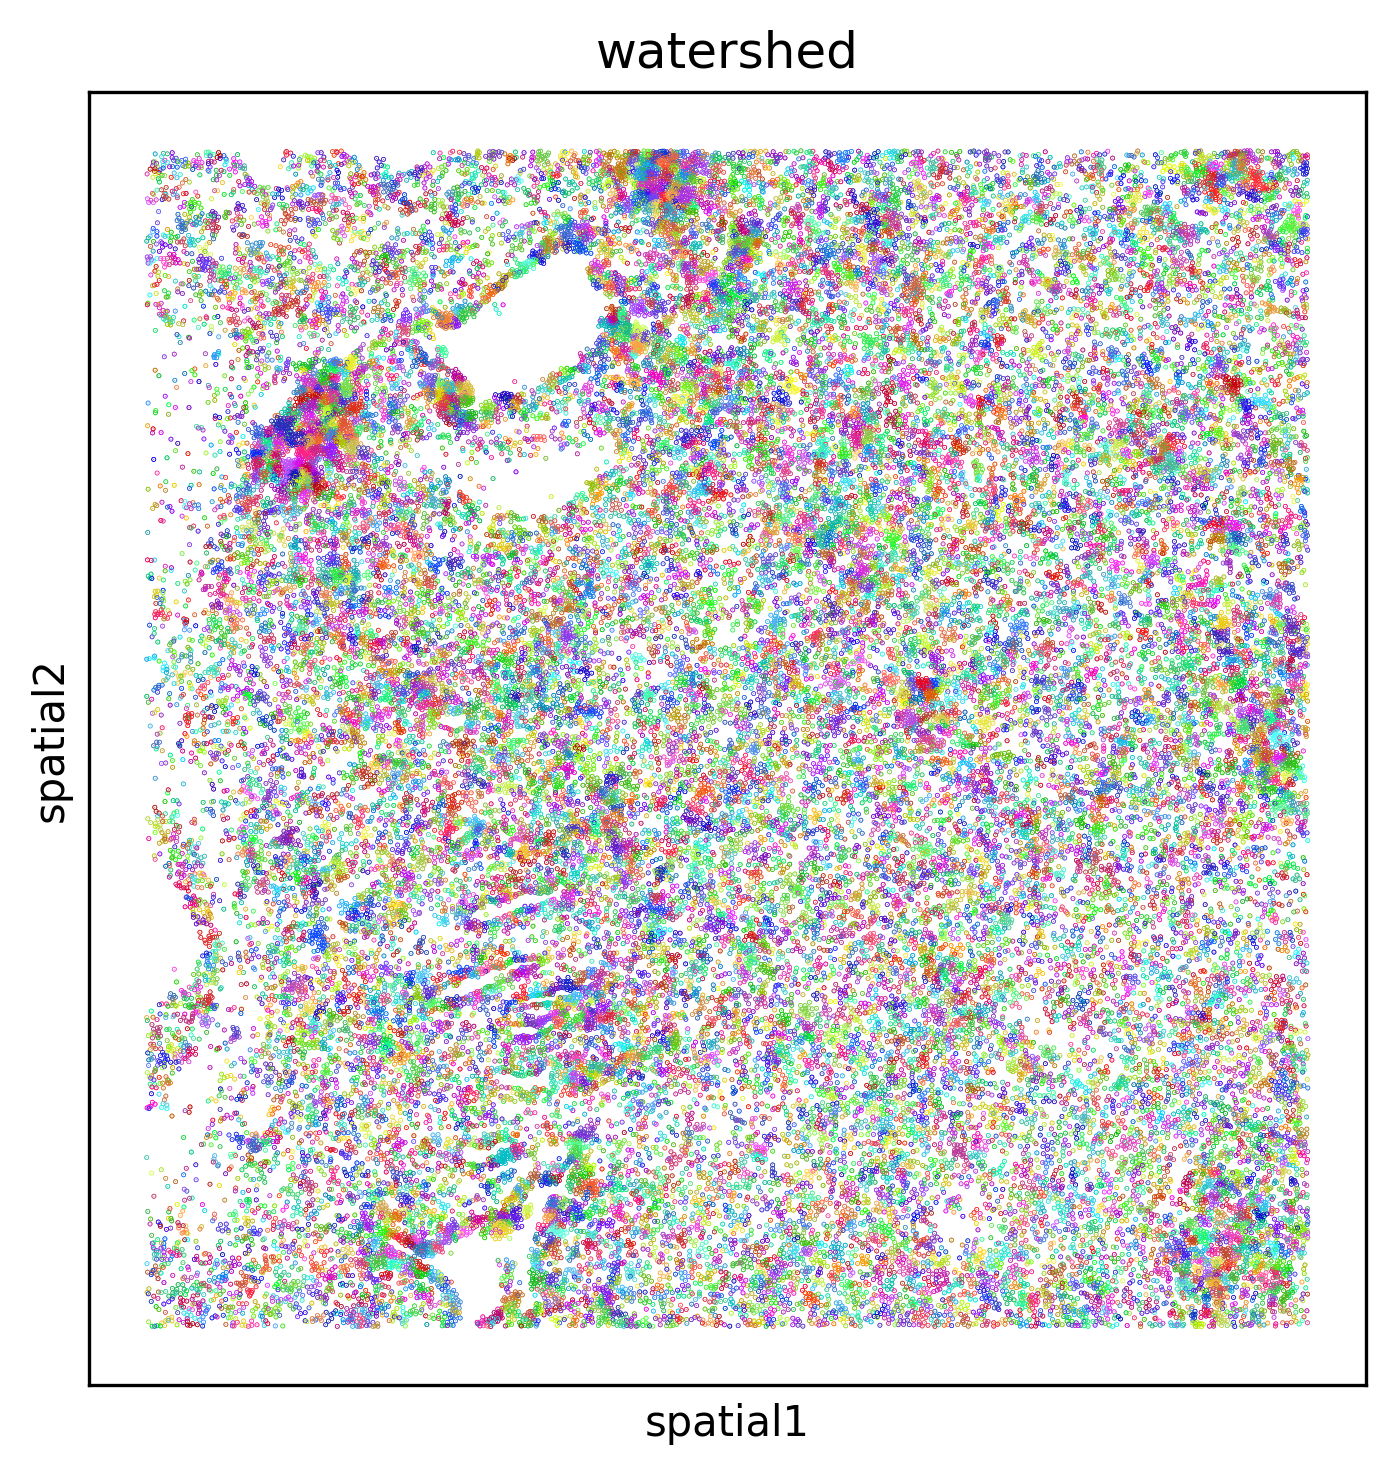

In [6]:
sq.pl.spatial_scatter(adata, color=["watershed"], shape=None, legend_loc=None, dpi=300, size=0.1)

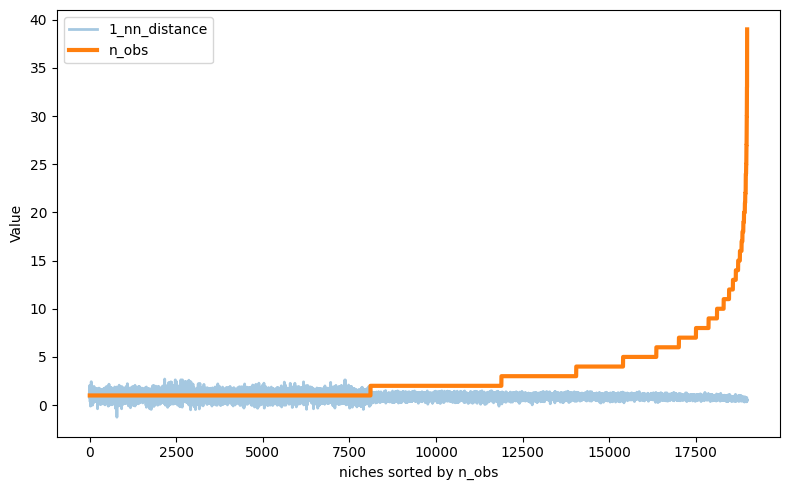

In [5]:
plotting.plot_niche_stats(adata, col_keys=["1_nn_distance","n_obs"], category_key="watershed", sort_by="n_obs", normalize=False)